In [3]:
import analyze
import pandas as pd

In [2]:
df = analyze.load_dataset("./data/processed/feature_dataset.csv")
df

,sequential_execution_time,average_parallel_line_executions,parallel_execution_fraction,arrays_count,total_array_elements,total_array_size_bytes,avg_array_size_bytes,max_array_dimension,min_array_dimension,avg_array_dimension,...,parallelism_degree,is_power_of_two_threads,is_power_of_two_grid,potential_contention,oversubscription_factor,target_speedup,parallel_execution_time,program_name,launch_config,normalized_parallel_time
0,0.0,11.750000,0.405172,2,2,8,4.0,1,1,1.0,...,1,1,1,0,1.0,0.0,0.0503,acr1101,grid=[1]_threads=1,inf
1,0.0,11.750000,0.405172,2,2,8,4.0,1,1,1.0,...,2,1,1,1,2.0,0.0,0.0401,acr1101,grid=[1]_threads=2,inf
2,0.0,11.750000,0.405172,2,2,8,4.0,1,1,1.0,...,3,0,1,1,3.0,0.0,0.0514,acr1101,grid=[1]_threads=3,inf
3,0.0,11.750000,0.405172,2,2,8,4.0,1,1,1.0,...,4,1,1,1,4.0,0.0,0.0509,acr1101,grid=[1]_threads=4,inf
4,0.0,11.750000,0.405172,2,2,8,4.0,1,1,1.0,...,5,0,1,1,5.0,0.0,0.0480,acr1101,grid=[1]_threads=5,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5140,0.0,2092.947368,0.998418,1,1,4,4.0,1,1,1.0,...,64,1,1,1,16.0,0.0,0.0007,distr42,grid=[4]_threads=16,inf
5141,0.0,2092.947368,0.998418,1,1,4,4.0,1,1,1.0,...,36,0,0,1,6.0,0.0,0.0009,distr42,grid=[6]_threads=6,inf
5142,0.0,2092.947368,0.998418,1,1,4,4.0,1,1,1.0,...,72,0,0,1,12.0,0.0,0.0011,distr42,grid=[6]_threads=12,inf
5143,0.0,2092.947368,0.998418,1,1,4,4.0,1,1,1.0,...,49,0,0,1,7.0,0.0,0.0011,distr42,grid=[7]_threads=7,inf


In [16]:
target_col = "parallel_execution_time"
name_col = "program_name"

zeros_only = df.groupby(name_col)[target_col].apply(lambda s: (s < 0.01).all())
programs = zeros_only[zeros_only].index.tolist()

pd.Series(programs, name=name_col).to_csv("programs.csv", index=False)

In [7]:
df[name_col].nunique()

128

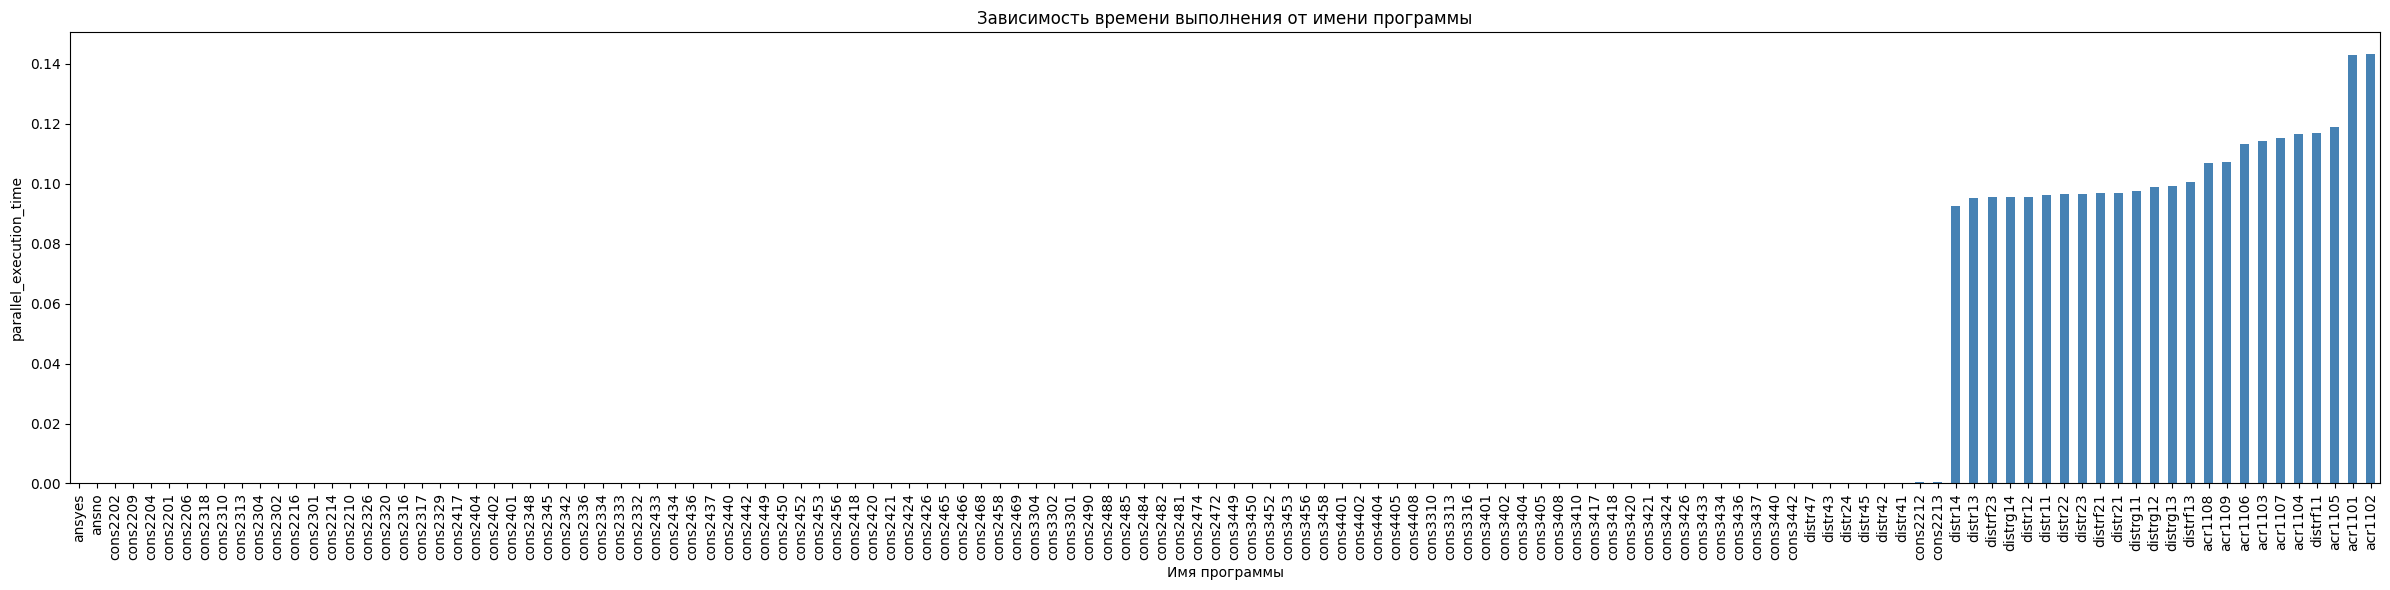

In [12]:
import matplotlib.pyplot as plt

program_time = (
    df.groupby(name_col)[target_col]
    .median()  # можно заменить на mean(), если нужен средний показатель
    .sort_values()
)

plt.figure(figsize=(24, 6))
program_time.plot(kind="bar", color="steelblue")
plt.title("Зависимость времени выполнения от имени программы")
plt.xlabel("Имя программы")
plt.ylabel(target_col)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()